In [1]:
!pip install seaborn
!pip install torch
!pip install torchvision
!pip install scikit-learn
!pip install timm

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


Detected Classes: ['DeepFakeDetection', 'FaceShifter', 'FaceSwap', 'NeuraTextures', 'deepfakes', 'face2face', 'original']
Number of Classes: 7


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


  0%|          | 0.00/104M [00:00<?, ?B/s]

[Epoch 1/20] [Batch 766 / 766] [Loss: 1.127099, Acc: 60.68%]
Evaluating...
[Batch 110 / 110]  [Loss: 0.485121, Acc: 83.88%]
Average Accuracy: 83.88%
Saving best model with validation accuracy: 83.88%
[Epoch 2/20] [Batch 766 / 766] [Loss: 0.391364, Acc: 87.18%]
Evaluating...
[Batch 110 / 110]  [Loss: 0.301942, Acc: 89.57%]
Average Accuracy: 89.57%
Saving best model with validation accuracy: 89.57%
[Epoch 3/20] [Batch 766 / 766] [Loss: 0.237093, Acc: 92.15%]
Evaluating...
[Batch 110 / 110]  [Loss: 0.259533, Acc: 90.80%]
Average Accuracy: 90.80%
Saving best model with validation accuracy: 90.80%
[Epoch 4/20] [Batch 766 / 766] [Loss: 0.158722, Acc: 94.84%]
Evaluating...
[Batch 110 / 110]  [Loss: 0.260320, Acc: 90.83%]
Average Accuracy: 90.83%
Saving best model with validation accuracy: 90.83%
[Epoch 5/20] [Batch 766 / 766] [Loss: 0.115104, Acc: 96.37%]
Evaluating...
[Batch 110 / 110]  [Loss: 0.272306, Acc: 90.71%]
Average Accuracy: 90.71%
[Epoch 6/20] [Batch 766 / 766] [Loss: 0.087806, Acc

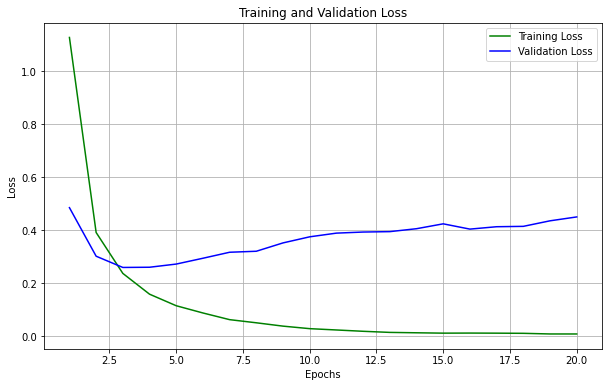

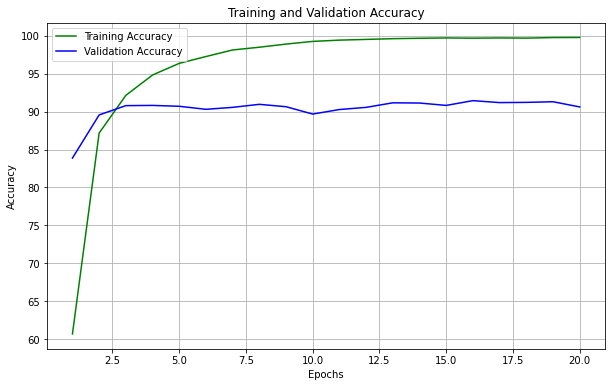


--- Evaluating on Test Set ---

Evaluating...
[Batch 219 / 219]  [Loss: 0.411086, Acc: 91.40%]
Average Accuracy: 91.40%


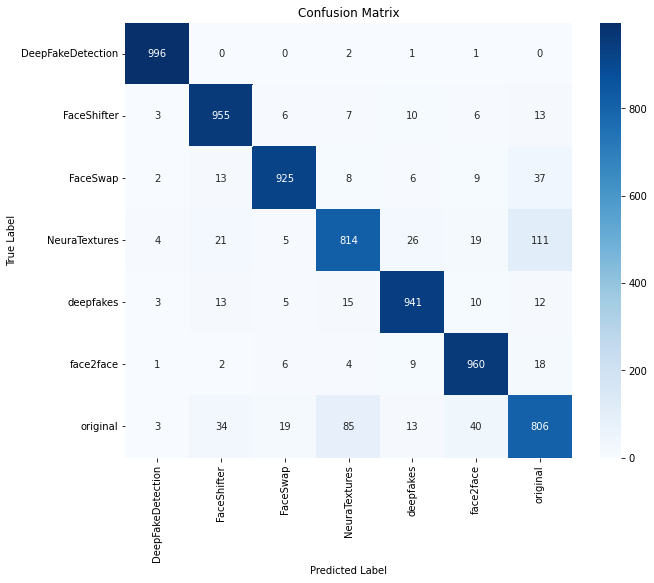

Test Accuracy: 91.40%
Test Loss: 0.4111


In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import os
import sys

# --- Definição dos Caminhos e Transformações ---
# Define the paths to your dataset
TRAIN_DIR = "./face_extraction/faceforensis_face_extract/train/"
VAL_DIR = "./face_extraction/faceforensis_face_extract/val/"
TEST_DIR = "./face_extraction/faceforensis_face_extract/test/"

# Define image transformations for InceptionV3 (299x299 input)
transform = transforms.Compose([
    transforms.Resize((299, 299)), # InceptionV3 expects 299x299
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)

# Get class names
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Detected Classes: {class_names}")
print(f"Number of Classes: {num_classes}")

# Create data loaders
batch_size = 32 # You can adjust this, consider memory usage for InceptionV3
# Using num_workers=0 to avoid shared memory issues, as discussed previously
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# --- Definição do Modelo InceptionV3 ---
class Model(nn.Module):
    def __init__(self, num_classes):
        super(Model, self).__init__()
        # Load InceptionV3 with pre-trained weights
        # aux_logits=False to simplify the forward pass, removing the auxiliary output
        self.inception_model = models.inception_v3(pretrained=True, aux_logits=False)
        
        # Replace the final classification layer
        # The last fully connected layer of InceptionV3 is 'fc'
        # The input features to this layer are 2048 for InceptionV3
        self.inception_model.fc = nn.Linear(self.inception_model.fc.in_features, num_classes)
        
    def forward(self, x):
        # InceptionV3's forward method directly gives the logits for classification
        # when aux_logits is False
        output = self.inception_model(x)
        return output

# --- Inicialização do Modelo, Otimizador e Critério ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(num_classes=num_classes).to(device)

# Hyperparameters (mantidos do código anterior)
lr = 1e-5
num_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss().to(device)

# --- Classes Auxiliares e Funções (sem alterações, pois são genéricas) ---
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def calculate_accuracy(outputs, targets):
    batch_size = targets.size(0)
    _, pred = outputs.topk(1, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.float().sum().item()
    return 100 * n_correct_elems / batch_size

def train_epoch(epoch, epochs_count, data_loader, model, criterion, optimizer):
    model.train()
    average_losses = AverageMeter()
    average_accuracy = AverageMeter()
    
    for i, (inputs, targets) in enumerate(data_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        accuracy = calculate_accuracy(outputs, targets)

        average_losses.update(loss.item(), inputs.size(0))
        average_accuracy.update(accuracy, inputs.size(0))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sys.stdout.write(
            "\r[Epoch %d/%d] [Batch %d / %d] [Loss: %f, Acc: %.2f%%]"
            % (
                epoch,
                epochs_count,
                i + 1,
                len(data_loader),
                average_losses.avg,
                average_accuracy.avg
            )
        )
    return average_losses.avg, average_accuracy.avg

def evaluate_model(epoch, model, data_loader, criterion):
    print('\nEvaluating...')
    model.eval()
    average_losses = AverageMeter()
    average_accuracy = AverageMeter()
    all_predictions = []
    all_actual_values = []
    
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(data_loader):
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            accuracy = calculate_accuracy(outputs, targets)
            
            _, predicted = torch.max(outputs, 1)
            all_actual_values.extend(targets.cpu().numpy().tolist())
            all_predictions.extend(predicted.cpu().numpy().tolist())

            average_losses.update(loss.item(), inputs.size(0))
            average_accuracy.update(accuracy, inputs.size(0))

            sys.stdout.write(
                "\r[Batch %d / %d]  [Loss: %f, Acc: %.2f%%]"
                % (
                    i + 1,
                    len(data_loader),
                    average_losses.avg,
                    average_accuracy.avg
                )
            )
        print(f'\nAverage Accuracy: {average_accuracy.avg:.2f}%')
    return all_actual_values, all_predictions, average_losses.avg, average_accuracy.avg

def plot_metrics(train_metrics, val_metrics, metric_name, num_epochs):
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_metrics, 'g', label=f'Training {metric_name}')
    plt.plot(epochs, val_metrics, 'b', label=f'Validation {metric_name}')
    plt.title(f'Training and Validation {metric_name}')
    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True)
    plt.show()

def print_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# --- Loop de Treinamento ---
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0.0
best_model_path = 'best_inceptionv3_model_multiclass.h5' # Nome do arquivo alterado para refletir o InceptionV3

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    # Train
    train_loss, train_acc = train_epoch(epoch, num_epochs, train_loader, model, criterion, optimizer)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validate
    actual_val, predicted_val, val_loss, val_acc = evaluate_model(epoch, model, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save the best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Saving best model with validation accuracy: {best_val_accuracy:.2f}%")

end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining completed in {training_time:.2f} seconds.")

# --- Plotagem de Métricas e Matriz de Confusão ---
plot_metrics(train_losses, val_losses, 'Loss', num_epochs)
plot_metrics(train_accuracies, val_accuracies, 'Accuracy', num_epochs)

# Evaluate on the test set and display confusion matrix
print("\n--- Evaluating on Test Set ---")
actual_test, predicted_test, test_loss, test_accuracy = evaluate_model("Final", model, test_loader, criterion)
print_confusion_matrix(actual_test, predicted_test, class_names)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")